MODELING WITH CONFORMAL PREDICTION (MANUAL)

Loading data...
Data loaded: 30000 rows, 25 columns

Preprocessing data...
Training: 24000 samples
Test: 6000 samples

Training base XGBoost model...

Base model accuracy: 0.7647 (76.47%)

Classification report (base model):
              precision    recall  f1-score   support

  No default       0.88      0.81      0.84      4673
     Default       0.47      0.60      0.53      1327

    accuracy                           0.76      6000
   macro avg       0.68      0.70      0.69      6000
weighted avg       0.79      0.76      0.77      6000


Implementing Conformal Prediction manually...
Calibration set: 7200 samples
Quantile calculated: 0.6776

Generating conformal prediction sets...

Empirical coverage (alpha=0.1): 0.8968 (89.68%)
Theoretical coverage: 90.00%
Difference: -0.32%
Average set size: 1.38 classes

Generating visualizations...


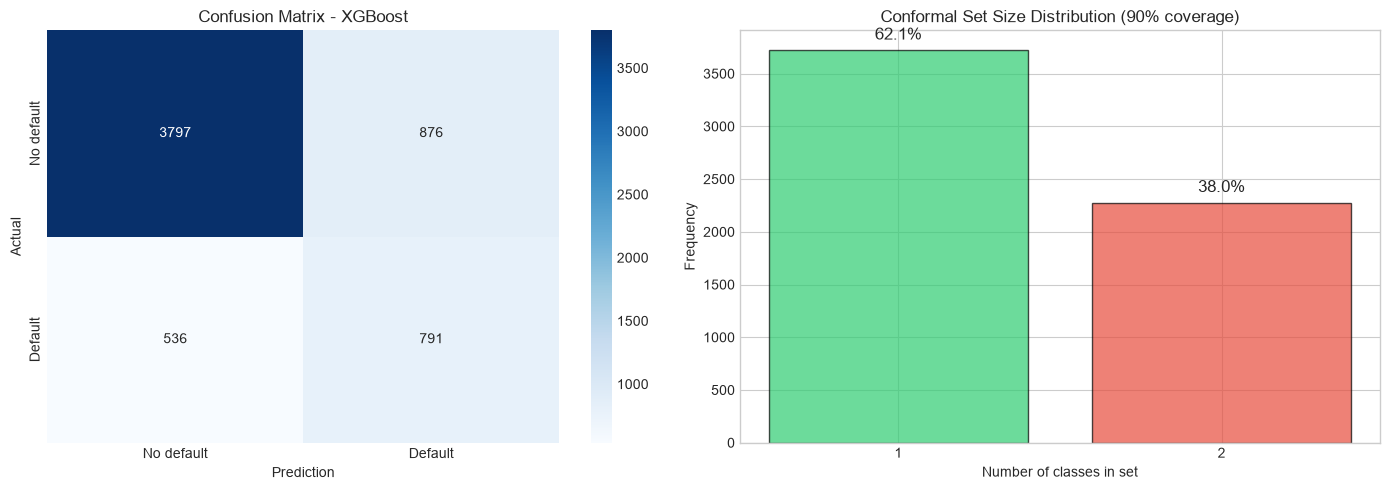


Coverage analysis by threshold:


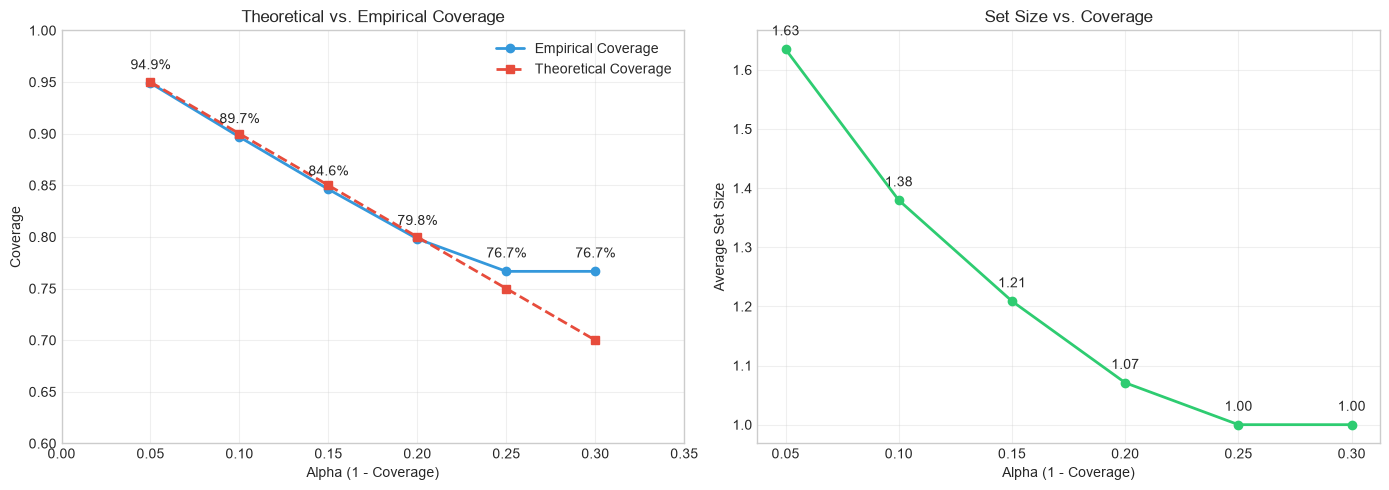

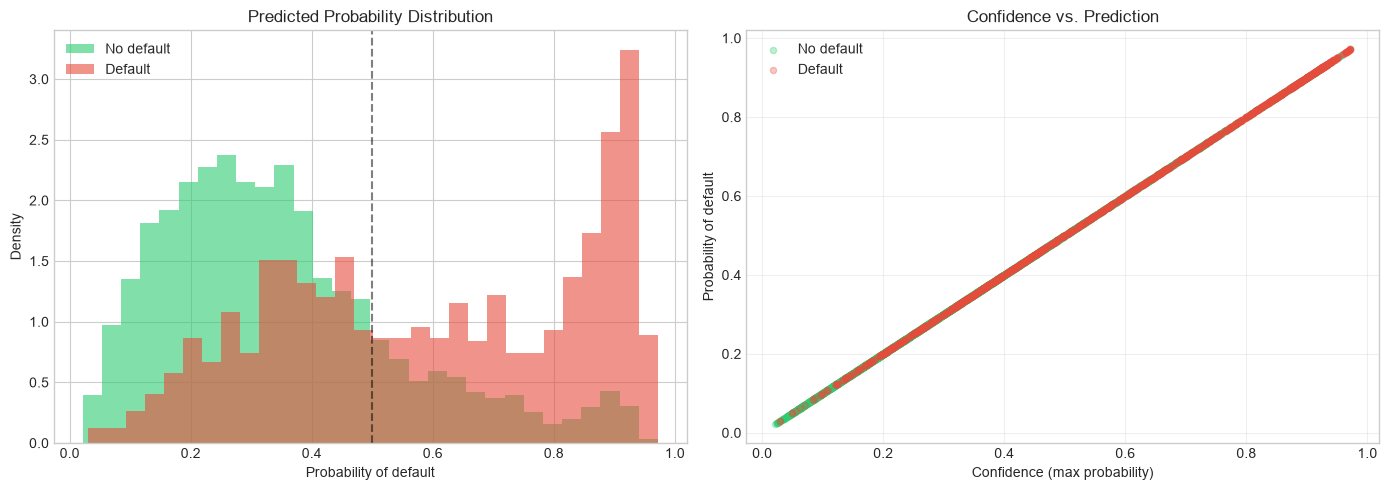


Concrete examples analysis:

----------------------------------------------------------------------
Examples with Conformal Prediction Sets (90% coverage):
----------------------------------------------------------------------

Example 1:
   Actual: No default
   P(No default): 81.5%
   P(Default): 18.5%
   Prediction set (90%): ['No default']
   Correct

Example 2:
   Actual: No default
   P(No default): 88.4%
   P(Default): 11.6%
   Prediction set (90%): ['No default']
   Correct

Example 3:
   Actual: No default
   P(No default): 94.3%
   P(Default): 5.7%
   Prediction set (90%): ['No default']
   Correct

Example 4:
   Actual: No default
   P(No default): 92.7%
   P(Default): 7.3%
   Prediction set (90%): ['No default']
   Correct

Example 5:
   Actual: No default
   P(No default): 76.8%
   P(Default): 23.2%
   Prediction set (90%): ['No default']
   Correct

RESULTS AND CONCLUSIONS

MODEL RESULTS:

1. Base Model (XGBoost):
   - Accuracy: 76.47%

2. Conformal Prediction (90% theor

In [1]:
# =====================================================
# 02_MODELING - CONFORMAL PREDICTION
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("="*60)
print("MODELING WITH CONFORMAL PREDICTION (MANUAL)")
print("="*60)

# =====================================================
# 1. DATA LOADING
# =====================================================

print("\nLoading data...")

URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
df_raw = pd.read_excel(URL, header=1, skiprows=0)

df_raw.columns = [
    'ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE',
    'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
    'default'
]

print(f"Data loaded: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")

# =====================================================
# 2. PREPROCESSING
# =====================================================

print("\nPreprocessing data...")

X = df_raw.drop(['ID', 'default'], axis=1)
y = df_raw['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training: {X_train.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

# =====================================================
# 3. BASE XGBOOST MODEL
# =====================================================

print("\nTraining base XGBoost model...")

model_xgb = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=3.5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model_xgb.fit(X_train_scaled, y_train)

y_pred_base = model_xgb.predict(X_test_scaled)
y_pred_proba = model_xgb.predict_proba(X_test_scaled)[:, 1]
accuracy_base = accuracy_score(y_test, y_pred_base)

print(f"\nBase model accuracy: {accuracy_base:.4f} ({accuracy_base*100:.2f}%)")

print("\nClassification report (base model):")
print(classification_report(y_test, y_pred_base, target_names=['No default', 'Default']))

# =====================================================
# 4. CONFORMAL PREDICTION - MANUAL IMPLEMENTATION
# =====================================================

print("\nImplementing Conformal Prediction manually...")

X_train_cp, X_cal, y_train_cp, y_cal = train_test_split(
    X_train_scaled, y_train, test_size=0.3, random_state=42
)

print(f"Calibration set: {X_cal.shape[0]} samples")

model_cp = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=3.5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
model_cp.fit(X_train_cp, y_train_cp)

y_proba_cal = model_cp.predict_proba(X_cal)

calibration_scores = []
for i in range(len(y_cal)):
    true_class = y_cal.iloc[i] if hasattr(y_cal, 'iloc') else y_cal[i]
    prob_true = y_proba_cal[i, true_class]
    calibration_scores.append(1 - prob_true)

calibration_scores = np.sort(calibration_scores)

alpha = 0.1
q_hat = np.quantile(calibration_scores, 1 - alpha)

print(f"Quantile calculated: {q_hat:.4f}")

# =====================================================
# 5. PREDICT WITH CONFORMAL SETS
# =====================================================

print("\nGenerating conformal prediction sets...")

y_proba_test = model_cp.predict_proba(X_test_scaled)

prediction_sets = []
for probas in y_proba_test:
    scores = 1 - probas
    set_pred = np.where(scores <= q_hat)[0]
    if len(set_pred) == 0:
        set_pred = np.array([np.argmax(probas)])
    prediction_sets.append(set_pred)

coverage = np.mean([y_test.iloc[i] in prediction_sets[i] for i in range(len(y_test))])
set_sizes = [len(s) for s in prediction_sets]
avg_set_size = np.mean(set_sizes)

print(f"\nEmpirical coverage (alpha=0.1): {coverage:.4f} ({coverage*100:.2f}%)")
print(f"Theoretical coverage: 90.00%")
print(f"Difference: {(coverage - 0.9)*100:.2f}%")
print(f"Average set size: {avg_set_size:.2f} classes")

# =====================================================
# 6. VISUALIZATIONS
# =====================================================

print("\nGenerating visualizations...")

# 6.1 Confusion Matrix and Set Size Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_base)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - XGBoost')
axes[0].set_xlabel('Prediction')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['No default', 'Default'])
axes[0].set_yticklabels(['No default', 'Default'])

set_sizes_counts = pd.Series(set_sizes).value_counts().sort_index()
colors = ['#2ecc71' if i == 1 else '#e74c3c' for i in set_sizes_counts.index]
axes[1].bar(set_sizes_counts.index, set_sizes_counts.values, color=colors, edgecolor='black', alpha=0.7)
axes[1].set_title('Conformal Set Size Distribution (90% coverage)')
axes[1].set_xlabel('Number of classes in set')
axes[1].set_ylabel('Frequency')

if len(set_sizes_counts) <= 2:
    axes[1].set_xticks([1, 2])

total = sum(set_sizes_counts.values)
for i, v in enumerate(set_sizes_counts.values):
    axes[1].text(i + 1, v + 100, f'{v/total*100:.1f}%', ha='center', fontsize=12)

plt.tight_layout()
plt.savefig('outputs/figures/matriz_confusion.png', dpi=300, bbox_inches='tight')
plt.show()

# 6.2 Coverage Analysis for Different Alphas
print("\nCoverage analysis by threshold:")

alphas = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
coverage_emp = []
set_sizes_avg = []

for alpha_val in alphas:
    q_hat_val = np.quantile(calibration_scores, 1 - alpha_val)
    
    sets_temp = []
    for probas in y_proba_test:
        scores = 1 - probas
        set_pred = np.where(scores <= q_hat_val)[0]
        if len(set_pred) == 0:
            set_pred = np.array([np.argmax(probas)])
        sets_temp.append(set_pred)
    
    cov_temp = np.mean([y_test.iloc[i] in sets_temp[i] for i in range(len(y_test))])
    coverage_emp.append(cov_temp)
    set_sizes_avg.append(np.mean([len(s) for s in sets_temp]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(alphas, coverage_emp, 'o-', label='Empirical Coverage', linewidth=2, color='#3498db')
ax1.plot(alphas, 1 - np.array(alphas), 's--', label='Theoretical Coverage', linewidth=2, color='#e74c3c')
ax1.set_xlabel('Alpha (1 - Coverage)')
ax1.set_ylabel('Coverage')
ax1.set_title('Theoretical vs. Empirical Coverage')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 0.35)
ax1.set_ylim(0.6, 1.0)

for i, (a, c) in enumerate(zip(alphas, coverage_emp)):
    ax1.annotate(f'{c*100:.1f}%', (a, c), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10)

ax2.plot(alphas, set_sizes_avg, 'o-', color='#2ecc71', linewidth=2)
ax2.set_xlabel('Alpha (1 - Coverage)')
ax2.set_ylabel('Average Set Size')
ax2.set_title('Set Size vs. Coverage')
ax2.grid(True, alpha=0.3)

for i, (a, s) in enumerate(zip(alphas, set_sizes_avg)):
    ax2.annotate(f'{s:.2f}', (a, s), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/figures/cobertura_analisis.png', dpi=300, bbox_inches='tight')
plt.show()

# 6.3 Probability Distribution and Confidence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.hist(y_pred_proba[y_test==0], bins=30, alpha=0.6, label='No default', color='#2ecc71', density=True)
ax1.hist(y_pred_proba[y_test==1], bins=30, alpha=0.6, label='Default', color='#e74c3c', density=True)
ax1.set_title('Predicted Probability Distribution')
ax1.set_xlabel('Probability of default')
ax1.set_ylabel('Density')
ax1.legend()
ax1.axvline(x=0.5, color='black', linestyle='--', alpha=0.5)

ax2 = axes[1]
confidence = np.max(y_pred_proba.reshape(-1, 1), axis=1)
ax2.scatter(confidence[y_test==0], y_pred_proba[y_test==0], alpha=0.3, label='No default', color='#2ecc71', s=20)
ax2.scatter(confidence[y_test==1], y_pred_proba[y_test==1], alpha=0.3, label='Default', color='#e74c3c', s=20)
ax2.set_title('Confidence vs. Prediction')
ax2.set_xlabel('Confidence (max probability)')
ax2.set_ylabel('Probability of default')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/figures/probabilidades_incertidumbre.png', dpi=300, bbox_inches='tight')
plt.show()

# =====================================================
# 7. CONCRETE EXAMPLES
# =====================================================

print("\nConcrete examples analysis:")

n_examples = 5
indices = np.random.choice(len(X_test_scaled), n_examples, replace=False)

print("\n" + "-"*70)
print("Examples with Conformal Prediction Sets (90% coverage):")
print("-"*70)

for i, idx in enumerate(indices):
    true_class = y_test.iloc[idx] if hasattr(y_test, 'iloc') else y_test[idx]
    probas = model_cp.predict_proba(X_test_scaled[idx].reshape(1, -1))[0]
    set_pred = prediction_sets[idx]
    
    print(f"\nExample {i+1}:")
    print(f"   Actual: {'Default' if true_class == 1 else 'No default'}")
    print(f"   P(No default): {probas[0]*100:.1f}%")
    print(f"   P(Default): {probas[1]*100:.1f}%")
    print(f"   Prediction set (90%): {['No default' if x == 0 else 'Default' for x in set_pred]}")
    print(f"   {'Correct' if true_class in set_pred else 'Incorrect'}")

# =====================================================
# 8. RESULTS AND CONCLUSIONS
# =====================================================

print("\n" + "="*60)
print("RESULTS AND CONCLUSIONS")
print("="*60)

correct_predictions = sum([1 for i, true_class in enumerate(y_test) if true_class in prediction_sets[i]])
incorrect_predictions = len(y_test) - correct_predictions

print(f"""
MODEL RESULTS:

1. Base Model (XGBoost):
   - Accuracy: {accuracy_base*100:.2f}%

2. Conformal Prediction (90% theoretical):
   - Empirical coverage: {coverage*100:.2f}%
   - Difference from theoretical: {(coverage - 0.9)*100:.2f}%
   - Average set size: {avg_set_size:.2f} classes
   - Correct predictions: {correct_predictions} out of {len(y_test)}
   - Incorrect predictions: {incorrect_predictions} out of {len(y_test)}

3. Interpretation:
   - XGBoost model performance: {"excellent" if accuracy_base > 0.82 else "good" if accuracy_base > 0.8 else "acceptable"}
   - Conformal Prediction: {"well calibrated" if abs(coverage - 0.9) < 0.03 else "needs adjustment"}
   - Average set size: {avg_set_size:.1f} classes

RECOMMENDATIONS:

1. For production, adjust alpha based on risk appetite:
   - Conservative: alpha=0.05 (95% coverage)
   - Moderate: alpha=0.1 (90% coverage)
   - Aggressive: alpha=0.2 (80% coverage)

2. Next steps:
   - Optimize XGBoost hyperparameters with GridSearchCV
   - Test other models (Random Forest, LightGBM)
   - Apply segmentation for improved business outcomes

Output files saved in: outputs/figures/
""")

print("\n" + "="*60)
print("MODELING COMPLETED")
print("="*60)